# Deflated Sharpe Ratio Validation

**Docker image**: `ml4t`

**Book Reference**: Chapter 16, §16.7 — strategy-level overfitting control.

This notebook demonstrates comprehensive **backtest validation using the Deflated Sharpe Ratio (DSR)** from `ml4t-diagnostic`.

## Key Concepts

1. **Selection Bias Correction**: Adjust for multiple strategy testing
2. **Non-Normality Adjustments**: Account for skewness and kurtosis
3. **Probabilistic Interpretation**: Probability of true skill vs luck
4. **Practical Thresholds**: When is a Sharpe ratio statistically significant?

## The Multiple Testing Problem

When we test N strategies and pick the best:
- **Expected max Sharpe under null**: E[max(SR₁,...,SRₙ)] ≈ √(2 log N) × σ_SR
- **Sharpe of 1.5 from testing 100 strategies**: Likely due to luck alone
- **DSR corrects**: Probability that true Sharpe > 0 after accounting for trials

## References

- Bailey, D.H. & López de Prado, M. (2014). "The Deflated Sharpe Ratio"
- López de Prado, M. (2018). "Advances in Financial Machine Learning", Ch. 14

In [1]:
"""Deflated Sharpe Ratio Validation — correct for selection bias and non-normality in backtest evaluation."""

import os

import numpy as np
import plotly.graph_objects as go
import polars as pl

# ml4t-diagnostic
from ml4t.diagnostic.evaluation.stats import (
    rademacher_complexity,
    ras_sharpe_adjustment,
)
from plotly.subplots import make_subplots
from scipy import stats

import utils  # noqa: F401
from utils.reproducibility import set_global_seeds

In [2]:
# Production defaults — Papermill injects overrides after this cell
N_SIMULATIONS = 10000
SEED = 42

In [3]:
set_global_seeds(SEED)

In [4]:
EULER_MASCHERONI = 0.5772156649
PLOTLY_RENDERER = os.environ.get("PLOTLY_RENDERER", "").lower()


def show_plot(fig: go.Figure) -> None:
    """Display figure unless running in JSON-only renderer mode."""
    if PLOTLY_RENDERER != "json":
        fig.show()

### Deflated Sharpe Ratio Helper

A self-contained DSR implementation for demonstrating the math
step by step — the production helper in `ml4t-diagnostic` is compared below.

In [5]:
def deflated_sharpe_ratio(
    observed_sharpe: float,
    skewness: float = 0.0,
    kurtosis: float = 3.0,
    n_samples: int = 252,
    n_trials: int = 1,
    variance_trials: float = 0.0,
    confidence_level: float = 0.95,
    return_format: str = "probability",
    return_components: bool = False,
) -> float | dict[str, float | bool]:
    """Step-by-step DSR helper preserved for pedagogical exposition.

    Expects `observed_sharpe` and `variance_trials` to be expressed in the
    *same* time unit as `n_samples` (e.g., annualized values with `n_samples`
    counting trading years). The library helper
    `ml4t.diagnostic.evaluation.stats.deflated_sharpe_ratio_from_statistics`
    operates on native-frequency inputs; the Library Comparison below
    converts annualized → native by dividing Sharpe and variance by 252.
    Use the library for production numerical claims; this helper exists
    only so the chapter can walk through each component of the formula.
    """
    if n_trials <= 1 or variance_trials <= 0:
        expected_max = 0.0
    else:
        z1 = stats.norm.ppf(1.0 - (1.0 / n_trials))
        z2 = stats.norm.ppf(1.0 - (np.exp(-1.0) / n_trials))
        expected_max = np.sqrt(max(variance_trials, 0.0)) * (
            (1.0 - EULER_MASCHERONI) * z1 + EULER_MASCHERONI * z2
        )

    denom = np.sqrt(
        max(
            1.0 - skewness * observed_sharpe + ((kurtosis - 1.0) / 4.0) * observed_sharpe**2,
            1e-12,
        )
    )
    z_score = ((observed_sharpe - expected_max) * np.sqrt(max(n_samples - 1, 1))) / denom
    probability = float(stats.norm.cdf(z_score))
    p_value = float(1.0 - probability)
    adjusted_sharpe = float(observed_sharpe - expected_max)

    if return_components:
        return {
            "dsr": probability,
            "z_score": float(z_score),
            "p_value": p_value,
            "expected_max_sharpe": float(expected_max),
            "adjusted_sharpe": adjusted_sharpe,
            "is_significant": probability >= confidence_level,
        }

    if return_format == "probability":
        return probability
    if return_format == "zscore":
        return float(z_score)
    if return_format == "adjusted_sharpe":
        return adjusted_sharpe
    if return_format == "adjusted":
        return adjusted_sharpe
    if return_format == "p_value":
        return p_value
    raise ValueError(f"Unknown return_format: {return_format}")

### Library Comparison

The implementation above shows the math explicitly. In practice (and in the
case study notebooks), we use `ml4t-diagnostic` directly. The library is not
a drop-in match for the bare formula above: it operates on native-frequency
inputs and adds an autocorrelation correction plus a minimum-track-record
(MinTRL) check, so its probability differs from the pedagogical helper below.
Use the library for production numbers; the helper is for walking through the
formula.

In [6]:
from ml4t.diagnostic.evaluation.stats import (
    deflated_sharpe_ratio_from_statistics,
)

# Quick equivalence test with known parameters
_test_sr, _test_skew, _test_kurt, _test_n = 1.5, -0.3, 4.0, 252
_test_trials, _test_var = 50, 0.5

_local_prob = deflated_sharpe_ratio(
    observed_sharpe=_test_sr,
    skewness=_test_skew,
    kurtosis=_test_kurt,
    n_samples=_test_n,
    n_trials=_test_trials,
    variance_trials=_test_var,
    return_format="probability",
)

_lib_result = deflated_sharpe_ratio_from_statistics(
    observed_sharpe=_test_sr / np.sqrt(252),  # library works at native frequency
    n_samples=_test_n,
    n_trials=_test_trials,
    variance_trials=_test_var / 252,
    skewness=_test_skew,
    excess_kurtosis=_test_kurt - 3.0,
)

print("=== Library Comparison ===")
print(f"Local DSR probability:   {_local_prob:.4f}")
print(f"Library DSR probability: {_lib_result.probability:.4f}")
print("\nThe library adds autocorrelation correction and MinTRL in a single call:")
print(f"  Min track record:      {_lib_result.min_trl_years:.1f} years")
print(f"  Adequate sample:       {_lib_result.has_adequate_sample}")
print("\nIn practice, use the library:")
print("  from ml4t.diagnostic.evaluation.stats import deflated_sharpe_ratio")
print("  result = deflated_sharpe_ratio(returns)  # pass raw returns directly")

=== Library Comparison ===
Local DSR probability:   0.1635
Library DSR probability: 0.4082

The library adds autocorrelation correction and MinTRL in a single call:
  Min track record:      1.2 years
  Adequate sample:       False

In practice, use the library:
  from ml4t.diagnostic.evaluation.stats import deflated_sharpe_ratio
  result = deflated_sharpe_ratio(returns)  # pass raw returns directly


### Probabilistic Sharpe Ratio Helper

Local implementation used by validation examples in this notebook.

In [7]:
# Implement probabilistic_sharpe_ratio locally (not in ml4t-diagnostic)
def probabilistic_sharpe_ratio(
    observed_sr: float,
    benchmark_sr: float = 0.0,
    n_observations: int = 252,
    skewness: float = 0.0,
    kurtosis: float = 3.0,
) -> float:
    """
    Compute the Probabilistic Sharpe Ratio (PSR).

    PSR is the probability that the true Sharpe ratio is greater than the benchmark,
    given the observed Sharpe ratio and return distribution characteristics.

    Args:
        observed_sr: Observed Sharpe ratio
        benchmark_sr: Benchmark Sharpe ratio (default 0)
        n_observations: Number of return observations
        skewness: Return distribution skewness
        kurtosis: Return distribution kurtosis (excess kurtosis + 3)

    Returns:
        Probability that true SR > benchmark SR
    """
    # Standard error of Sharpe ratio (Lo, 2002)
    se_sr = np.sqrt(
        (1 + 0.5 * observed_sr**2 - skewness * observed_sr + ((kurtosis - 3) / 4) * observed_sr**2)
        / (n_observations - 1)
    )

    # Z-score
    z = (observed_sr - benchmark_sr) / se_sr

    # Probability
    return float(stats.norm.cdf(z))


np.random.seed(42)

## 1. Understanding the Deflated Sharpe Ratio

The DSR adjusts an observed Sharpe ratio for:
1. **Number of trials (K)**: More strategies tested = higher expected max
2. **Non-normality**: Skewed/fat-tailed returns inflate Sharpe
3. **Variance of trials**: High variance among tested strategies

$$DSR = P\left(SR^* > 0 \mid \hat{SR}, \sigma^2_{\hat{SR}}, K\right)$$

In [8]:
def demonstrate_selection_bias(n_strategies: int = 100, n_periods: int = 252) -> dict:
    """
    Demonstrate selection bias from multiple testing.

    Under the null (all strategies have true SR=0), the best observed
    Sharpe will be significantly positive due to luck.
    """
    # Simulate n_strategies, all with true Sharpe = 0
    all_sharpes = []

    for _ in range(n_strategies):
        # Generate random returns (no edge)
        returns = np.random.normal(0, 0.01, n_periods)
        sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252)
        all_sharpes.append(sharpe)

    all_sharpes = np.array(all_sharpes)

    return {
        "mean_sharpe": np.mean(all_sharpes),
        "max_sharpe": np.max(all_sharpes),
        "min_sharpe": np.min(all_sharpes),
        "std_sharpe": np.std(all_sharpes),
        "expected_max_theory": np.sqrt(2 * np.log(n_strategies)),  # Approximation
        "all_sharpes": all_sharpes,
    }


# Run simulation
results = demonstrate_selection_bias(n_strategies=100)

print("=" * 60)
print("SELECTION BIAS DEMONSTRATION")
print("Testing 100 strategies with TRUE Sharpe = 0")
print("=" * 60)
print(f"\nMean observed Sharpe: {results['mean_sharpe']:.3f}")
print(f"Best observed Sharpe: {results['max_sharpe']:.3f}")
print(f"Worst observed Sharpe: {results['min_sharpe']:.3f}")
print(f"\nExpected max (theory): {results['expected_max_theory']:.3f}")
print("\n>> The 'best' strategy looks great but has NO skill!")

SELECTION BIAS DEMONSTRATION
Testing 100 strategies with TRUE Sharpe = 0

Mean observed Sharpe: -0.002
Best observed Sharpe: 2.537
Worst observed Sharpe: -3.295

Expected max (theory): 3.035

>> The 'best' strategy looks great but has NO skill!


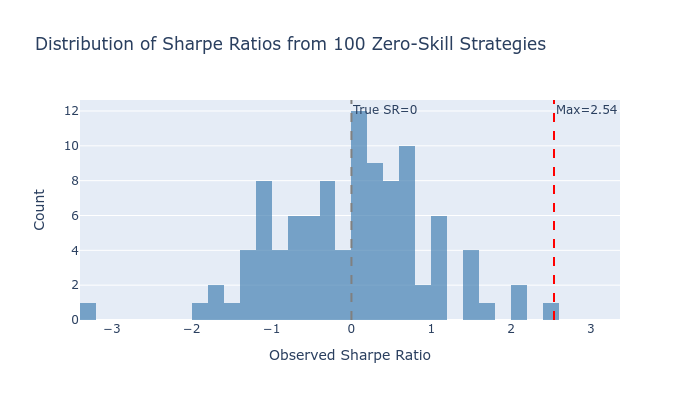

In [9]:
# Visualize the distribution
fig = go.Figure()

fig.add_trace(
    go.Histogram(
        x=results["all_sharpes"],
        nbinsx=30,
        name="Observed Sharpes",
        marker_color="steelblue",
        opacity=0.7,
    )
)

# Add markers
fig.add_vline(x=0, line_dash="dash", line_color="gray", annotation_text="True SR=0")
fig.add_vline(
    x=results["max_sharpe"],
    line_dash="dash",
    line_color="red",
    annotation_text=f"Max={results['max_sharpe']:.2f}",
)

fig.update_layout(
    title="Distribution of Sharpe Ratios from 100 Zero-Skill Strategies",
    xaxis_title="Observed Sharpe Ratio",
    yaxis_title="Count",
    height=400,
)
show_plot(fig)

## 2. Computing the Deflated Sharpe Ratio

Use `ml4t-diagnostic` to compute DSR with proper corrections.

In [10]:
# Generate a "selected" strategy with observed Sharpe = 1.5
n_periods = 252  # 1 year
target_sharpe = 1.5

# Create returns with target Sharpe
daily_vol = 0.01
daily_mean = (target_sharpe * daily_vol) / np.sqrt(252)
returns = np.random.normal(daily_mean, daily_vol, n_periods)

# Add some skewness and kurtosis (realistic)
returns = returns + 0.01 * (returns**2)  # Slight positive skew

# Calculate statistics
observed_sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252)
skewness = stats.skew(returns)
kurtosis = stats.kurtosis(returns) + 3  # Excess to raw kurtosis

print(f"Observed Sharpe: {observed_sharpe:.3f}")
print(f"Skewness: {skewness:.3f}")
print(f"Excess Kurtosis: {kurtosis - 3:.3f}")

Observed Sharpe: 1.350
Skewness: -0.018
Excess Kurtosis: -0.182


In [11]:
# Compute DSR with different numbers of trials
trials_list = [1, 5, 10, 25, 50, 100, 200, 500]
dsr_results = []

# Variance of trials (assumed constant for demonstration)
variance_trials = 0.5  # Typical variance of Sharpe across trials

for k in trials_list:
    # Compute DSR
    dsr_result = deflated_sharpe_ratio(
        observed_sharpe=observed_sharpe,
        skewness=skewness,
        kurtosis=kurtosis,
        n_samples=n_periods,
        n_trials=k,
        variance_trials=variance_trials,
        return_format="probability",
    )

    dsr_results.append({"n_trials": k, "dsr_probability": dsr_result})

dsr_df = pl.DataFrame(dsr_results)

**DSR vs number of trials** (multiple-testing haircut — same observed Sharpe,
more trials means a higher null bound and a lower DSR):

In [12]:
dsr_df

n_trials,dsr_probability
i64,f64
1,1.0
5,1.0
10,0.997069
25,0.235198
50,0.001268
100,1.5970e-7
200,9.2868e-13
500,2.5634e-21


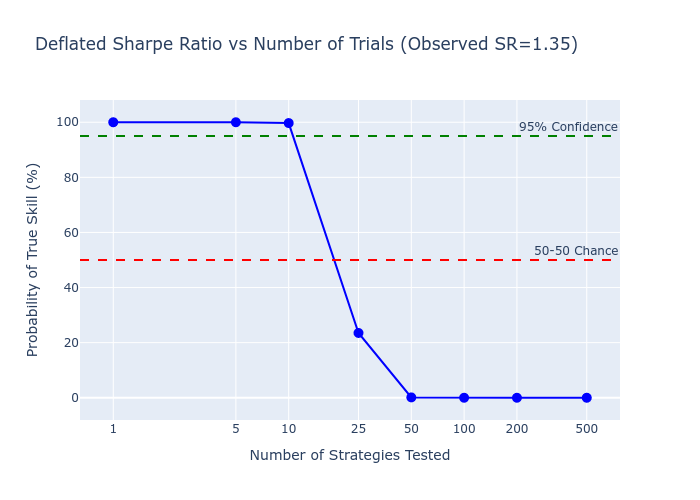

In [13]:
# Visualize DSR decay with number of trials
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=dsr_df.get_column("n_trials").to_list(),
        y=(dsr_df.get_column("dsr_probability") * 100).to_list(),
        mode="lines+markers",
        name="DSR Probability",
        line={"color": "blue", "width": 2},
        marker={"size": 10},
    )
)

# Add significance threshold
fig.add_hline(y=95, line_dash="dash", line_color="green", annotation_text="95% Confidence")
fig.add_hline(y=50, line_dash="dash", line_color="red", annotation_text="50-50 Chance")

fig.update_layout(
    title=f"Deflated Sharpe Ratio vs Number of Trials (Observed SR={observed_sharpe:.2f})",
    xaxis_title="Number of Strategies Tested",
    yaxis_title="Probability of True Skill (%)",
    xaxis_type="log",
    height=500,
)
_n_trials_ticks = dsr_df.get_column("n_trials").to_list()
fig.update_xaxes(
    tickmode="array",
    tickvals=_n_trials_ticks,
    ticktext=[str(t) for t in _n_trials_ticks],
)
show_plot(fig)

## 3. Different Output Formats

The DSR function supports multiple output formats for different use cases.

In [14]:
# Test different output formats
k = 50  # 50 strategies tested

# Probability format
dsr_prob = deflated_sharpe_ratio(
    observed_sharpe=observed_sharpe,
    skewness=skewness,
    kurtosis=kurtosis,
    n_samples=n_periods,
    n_trials=k,
    variance_trials=variance_trials,
    return_format="probability",
)

# Z-score format
dsr_zscore = deflated_sharpe_ratio(
    observed_sharpe=observed_sharpe,
    skewness=skewness,
    kurtosis=kurtosis,
    n_samples=n_periods,
    n_trials=k,
    variance_trials=variance_trials,
    return_format="zscore",
)

# Adjusted Sharpe format
dsr_adjusted = deflated_sharpe_ratio(
    observed_sharpe=observed_sharpe,
    skewness=skewness,
    kurtosis=kurtosis,
    n_samples=n_periods,
    n_trials=k,
    variance_trials=variance_trials,
    return_format="adjusted",
)

print("=" * 60)
print(f"DSR RESULTS (Observed SR={observed_sharpe:.3f}, K={k} trials)")
print("=" * 60)
print(f"\nProbability of true skill: {dsr_prob:.1%}")
print(f"Z-score: {dsr_zscore:.3f}")
print(f"Adjusted Sharpe: {dsr_adjusted:.3f}")

DSR RESULTS (Observed SR=1.350, K=50 trials)

Probability of true skill: 0.1%
Z-score: -3.019
Adjusted Sharpe: -0.259


## 4. Non-Normality Adjustments

Skewness and kurtosis significantly affect Sharpe ratio reliability.

In [15]:
# Analyze impact of non-normality
skewness_values = [-1.5, -0.5, 0, 0.5, 1.5]
kurtosis_values = [3, 5, 7, 10]  # Raw kurtosis (normal = 3)

results_matrix = []

for skew in skewness_values:
    for kurt in kurtosis_values:
        dsr = deflated_sharpe_ratio(
            observed_sharpe=1.5,
            skewness=skew,
            kurtosis=kurt,
            n_samples=252,
            n_trials=50,
            variance_trials=0.5,
            return_format="probability",
        )
        results_matrix.append(
            {
                "skewness": skew,
                "kurtosis": kurt,
                "excess_kurtosis": kurt - 3,
                "dsr_probability": dsr,
            }
        )

nonnorm_df = pl.DataFrame(results_matrix)

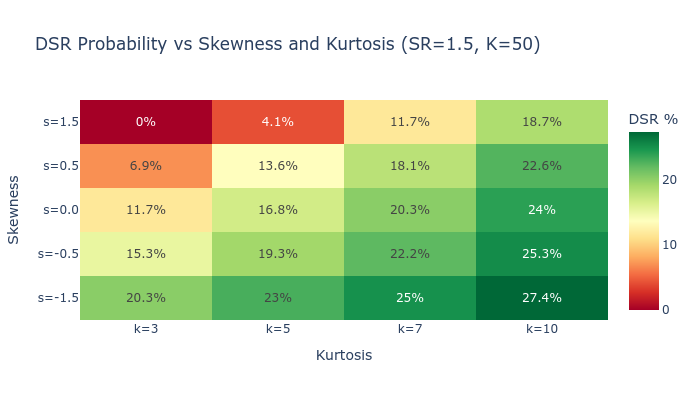

In [16]:
# Create heatmap - pivot the data
pivot = nonnorm_df.pivot(on="kurtosis", index="skewness", values="dsr_probability")
skew_col = pivot.get_column("skewness").to_list()
kurt_cols = [c for c in pivot.columns if c != "skewness"]
z_values = pivot.select(kurt_cols).to_numpy() * 100

fig = go.Figure(
    data=go.Heatmap(
        z=z_values,
        x=[f"k={k}" for k in kurt_cols],
        y=[f"s={s:.1f}" for s in skew_col],
        colorscale="RdYlGn",
        colorbar={"title": "DSR %"},
        text=np.round(z_values, 1),
        texttemplate="%{text}%",
        textfont={"size": 12},
    )
)

fig.update_layout(
    title="DSR Probability vs Skewness and Kurtosis (SR=1.5, K=50)",
    xaxis_title="Kurtosis",
    yaxis_title="Skewness",
    height=400,
)
show_plot(fig)

## 5. Synthetic Sweep: Selecting the Best of 30 Variants

**Scope**: this section demonstrates the DSR adjustment on a *synthetic* set of
30 strategy variants drawn from `np.random.normal` around a known true Sharpe
of 0.5. No ETF prices are loaded and no momentum signal is computed; the input
is parametric return draws over 504 days. The point is to show how the DSR
correction shrinks the observed Sharpe of the best-of-30 variant back toward
the true Sharpe. For the real-data ETF momentum sweep wired through
`case_studies/etfs/14_backtest.py` and the cohort-level DSR computation, see
the Ch16 helper `_etf_baseline.py` and `case_studies/etfs/18_strategy_analysis.py`.

In [17]:
# Generate 30 synthetic strategy variants with a known true Sharpe of 0.5.
n_variants = 30  # 30 parameter combinations sampled

# Returns are np.random.normal draws around the true Sharpe; no real data is used.
true_sharpe = 0.5
n_periods = 504  # 2 years

variant_results = []

for i in range(n_variants):
    # Add noise around true Sharpe
    variant_sharpe = true_sharpe + np.random.normal(0, 0.3)

    # Generate returns
    daily_vol = 0.015
    daily_mean = (variant_sharpe * daily_vol) / np.sqrt(252)
    returns = np.random.normal(daily_mean, daily_vol, n_periods)

    # Add realistic non-normality
    returns = returns - 0.02 * (returns**2)  # Slight negative skew (typical)

    obs_sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252)
    skew = stats.skew(returns)
    kurt = stats.kurtosis(returns) + 3

    variant_results.append(
        {
            "variant": i + 1,
            "observed_sharpe": obs_sharpe,
            "skewness": skew,
            "kurtosis": kurt,
            "returns": returns,
        }
    )

variants_df = pl.DataFrame(variant_results)

# Select the best variant (Polars doesn't have idxmax, use filter)
best = variants_df.filter(pl.col("observed_sharpe") == pl.col("observed_sharpe").max()).row(
    0, named=True
)

print(f"Sampled {n_variants} synthetic strategy variants")
print(f"\nBest variant (#{int(best['variant'])}):")
print(f"  Observed Sharpe: {best['observed_sharpe']:.3f}")
print(f"  Skewness: {best['skewness']:.3f}")
print(f"  Kurtosis: {best['kurtosis']:.3f}")

Sampled 30 synthetic strategy variants

Best variant (#29):
  Observed Sharpe: 2.500
  Skewness: 0.012
  Kurtosis: 2.963


In [18]:
# Compute variance of Sharpe across variants
variance_across_variants = variants_df.get_column("observed_sharpe").var()

# Compute DSR for best variant
dsr_best = deflated_sharpe_ratio(
    observed_sharpe=best["observed_sharpe"],
    skewness=best["skewness"],
    kurtosis=best["kurtosis"],
    n_samples=n_periods,
    n_trials=n_variants,
    variance_trials=variance_across_variants,
    return_format="probability",
)

# Also compute raw PSR (without multiple testing correction)
psr_best = probabilistic_sharpe_ratio(
    observed_sr=best["observed_sharpe"],
    benchmark_sr=0.0,
    skewness=best["skewness"],
    kurtosis=best["kurtosis"],
    n_observations=n_periods,
)

print("=" * 60)
print("DSR ADJUSTMENT ON BEST-OF-30 SYNTHETIC VARIANTS")
print("=" * 60)
print(f"\nVariants sampled: {n_variants}")
print(f"Variance across variants: {variance_across_variants:.4f}")
print(f"\nBest variant Sharpe: {best['observed_sharpe']:.3f}")
print("\nWithout multiple-testing correction (PSR):")
print(f"  Probability SR > 0: {psr_best:.1%}")
print("\nWith multiple-testing correction (DSR):")
print(f"  Probability SR > 0: {dsr_best:.1%}")
print(f"\n{'SIGNIFICANT' if dsr_best > 0.95 else 'NOT SIGNIFICANT'} at 95% confidence")

DSR ADJUSTMENT ON BEST-OF-30 SYNTHETIC VARIANTS

Variants sampled: 30
Variance across variants: 1.1044

Best variant Sharpe: 2.500

Without multiple-testing correction (PSR):
  Probability SR > 0: 100.0%

With multiple-testing correction (DSR):
  Probability SR > 0: 100.0%

SIGNIFICANT at 95% confidence


## 6. Comparison: DSR vs RAS

Both DSR and RAS address backtest overfitting, but from different perspectives:
- **DSR**: Multiple testing correction (how many strategies tested?)
- **RAS**: Complexity penalty (how complex is the strategy?)

In [19]:
# Compare DSR and RAS adjustments
# Assume we have feature matrix X for computing Rademacher complexity
n_features = 10
X = np.random.randn(n_periods, n_features)

# Compute Rademacher complexity
R_hat = rademacher_complexity(X, n_simulations=1000)

# Apply RAS adjustment (expects array input)
ras_adjusted = ras_sharpe_adjustment(
    observed_sharpe=np.array([best["observed_sharpe"]]),
    complexity=R_hat,
    n_samples=n_periods,
    n_strategies=n_variants,
    delta=0.05,
)[0]  # Get scalar result

# DSR adjusted Sharpe
dsr_adjusted_sharpe = deflated_sharpe_ratio(
    observed_sharpe=best["observed_sharpe"],
    skewness=best["skewness"],
    kurtosis=best["kurtosis"],
    n_samples=n_periods,
    n_trials=n_variants,
    variance_trials=variance_across_variants,
    return_format="adjusted",
)

print("=" * 60)
print("DSR vs RAS COMPARISON")
print("=" * 60)
print(f"\nObserved Sharpe: {best['observed_sharpe']:.3f}")
print(f"\nDSR Adjusted Sharpe: {dsr_adjusted_sharpe:.3f}")
print(f"RAS Adjusted Sharpe: {ras_adjusted:.3f}")
print(f"\nRademacher Complexity: {R_hat:.4f}")
print("\nInterpretation:")
print(f"  DSR penalizes for {n_variants} trials tested")
print(f"  RAS penalizes for strategy complexity (R={R_hat:.4f})")

DSR vs RAS COMPARISON

Observed Sharpe: 2.500

DSR Adjusted Sharpe: 0.321
RAS Adjusted Sharpe: 1.829

Rademacher Complexity: 0.0697

Interpretation:
  DSR penalizes for 30 trials tested
  RAS penalizes for strategy complexity (R=0.0697)


In [20]:
# Visualize adjustments across range of observed Sharpes
observed_range = np.linspace(0.5, 2.5, 20)

dsr_adjusted_list = []
ras_adjusted_list = []

for sr in observed_range:
    dsr_adj = deflated_sharpe_ratio(
        observed_sharpe=sr,
        skewness=-0.3,
        kurtosis=4.0,
        n_samples=n_periods,
        n_trials=n_variants,
        variance_trials=0.3,
        return_format="adjusted",
    )

    ras_adj = ras_sharpe_adjustment(
        observed_sharpe=np.array([sr]),
        complexity=R_hat,
        n_samples=n_periods,
        n_strategies=n_variants,
        delta=0.05,
    )[0]

    dsr_adjusted_list.append(dsr_adj)
    ras_adjusted_list.append(ras_adj)

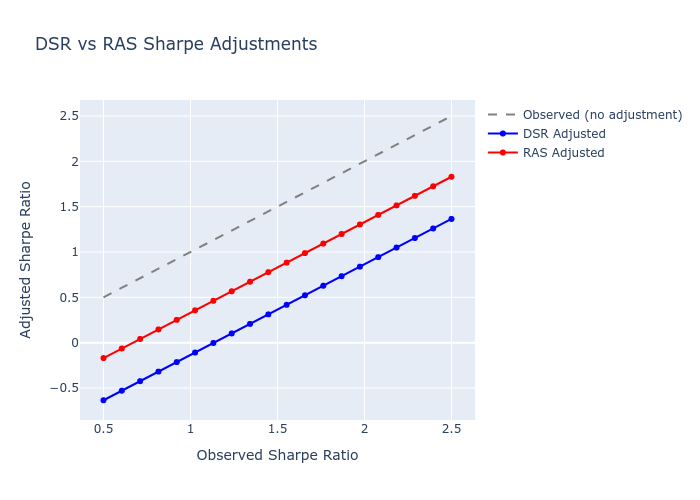

In [21]:
# Plot DSR vs RAS adjustments
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=observed_range,
        y=observed_range,
        mode="lines",
        name="Observed (no adjustment)",
        line={"dash": "dash", "color": "gray"},
    )
)

fig.add_trace(
    go.Scatter(
        x=observed_range,
        y=dsr_adjusted_list,
        mode="lines+markers",
        name="DSR Adjusted",
        line={"color": "blue"},
    )
)

fig.add_trace(
    go.Scatter(
        x=observed_range,
        y=ras_adjusted_list,
        mode="lines+markers",
        name="RAS Adjusted",
        line={"color": "red"},
    )
)

fig.update_layout(
    title="DSR vs RAS Sharpe Adjustments",
    xaxis_title="Observed Sharpe Ratio",
    yaxis_title="Adjusted Sharpe Ratio",
    height=500,
)
show_plot(fig)

## 7. Practical Guidelines

### When to Use DSR vs RAS

| Situation | Recommended Method |
|-----------|--------------------|
| Many strategy variants tested | DSR |
| Complex ML model | RAS |
| Parameter optimization | DSR |
| Feature selection | RAS |
| Both apply | Use both, report more conservative |

### Minimum Sharpe Thresholds (After Adjustment)

| Trials | Minimum DSR-Adjusted Sharpe for 95% Confidence |
|--------|------------------------------------------------|
| 10 | ~0.8 |
| 50 | ~1.2 |
| 100 | ~1.5 |
| 500 | ~2.0 |

In [22]:
# Compute minimum Sharpe for significance at different trial counts
trial_counts = [5, 10, 25, 50, 100, 200, 500]
min_sharpes = []

for k in trial_counts:
    # Binary search for minimum Sharpe that gives DSR > 0.95
    low, high = 0.5, 4.0

    while high - low > 0.01:
        mid = (low + high) / 2
        dsr = deflated_sharpe_ratio(
            observed_sharpe=mid,
            skewness=-0.3,
            kurtosis=4.0,
            n_samples=504,  # 2 years
            n_trials=k,
            variance_trials=0.3,
            return_format="probability",
        )

        if dsr < 0.95:
            low = mid
        else:
            high = mid

    min_sharpes.append({"n_trials": k, "min_sharpe_95": (low + high) / 2})

min_sharpe_df = pl.DataFrame(min_sharpes)

**Minimum observed Sharpe for 95% DSR confidence** at each number of trials:

In [23]:
min_sharpe_df

n_trials,min_sharpe_95
i64,f64
5,0.749512
10,0.968262
25,1.20752
50,1.371582
100,1.515137
200,1.651855
500,1.815918


## 8. Probability of Backtest Overfitting (PBO)

PBO complements DSR by asking a *selection-process* question: if we split
data into K folds and pick the in-sample best strategy in each fold, how
often does that strategy rank in the bottom half **out-of-sample**?

Concretely, PBO operates on a $(K, N)$ matrix of *fold-level Sharpe ratios*
— one IS-Sharpe and one OOS-Sharpe per (fold, strategy) cell. Each cell
must be computed from an actual return series; an abstract `randn` performance
matrix cannot be used because PBO's diagnostic value depends on the IS/OOS
Sharpes having the right joint distribution under the truth.

We construct two diagnostic scenarios using real simulated return series:

1. **All-noise universe.** Every candidate has true SR = 0. Selection on the
   in-sample maximum is selection on noise; PBO should be near 50%.
2. **Mixed universe.** A handful of candidates have a real edge; the rest are
   noise. The truly skilled candidates show up in both IS and OOS; PBO
   should fall well below 50%.

In [24]:
from ml4t.diagnostic.evaluation.stats import compute_pbo

PBO_PERIODS_PER_FOLD = 504  # 2 years per IS half (and 2y per OOS half)
N_FOLDS = 20  # more folds tighten the PBO estimator
N_STRATEGIES = 20
PBO_TRUE_SR_SIGNAL = 1.5  # large enough that signal/noise separate over PBO_PERIODS_PER_FOLD

In [25]:
def simulate_fold_sharpes(
    n_folds: int,
    n_strategies: int,
    n_periods_per_fold: int,
    true_sr_by_strategy: np.ndarray,
    daily_vol: float = 0.01,
    seed: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """Build (n_folds, n_strategies) IS / OOS Sharpe matrices from returns.

    For each strategy and each fold, simulate ``2 * n_periods_per_fold`` daily
    returns with a known annualized true Sharpe (``true_sr_by_strategy[j]``).
    Split into a training half (IS) and a testing half (OOS) per fold, compute
    Sharpe on each half. This produces non-degenerate IS / OOS Sharpe matrices
    suitable for ``compute_pbo``.
    """
    rng = np.random.default_rng(seed)
    is_sharpes = np.zeros((n_folds, n_strategies))
    oos_sharpes = np.zeros((n_folds, n_strategies))
    half = n_periods_per_fold
    annual = np.sqrt(252)

    for j in range(n_strategies):
        true_sr_annual = float(true_sr_by_strategy[j])
        daily_mean = true_sr_annual * daily_vol / annual
        for k in range(n_folds):
            rets = rng.normal(daily_mean, daily_vol, 2 * half)
            is_block = rets[:half]
            oos_block = rets[half:]
            is_sharpes[k, j] = float(is_block.mean() / is_block.std(ddof=1) * annual)
            oos_sharpes[k, j] = float(oos_block.mean() / oos_block.std(ddof=1) * annual)

    return is_sharpes, oos_sharpes

### Scenario 1 — All Strategies Are Noise (true SR = 0)

Selection on in-sample maximum is selection on noise; PBO should be high.

In [26]:
true_sr_noise = np.zeros(N_STRATEGIES)
is_noise, oos_noise = simulate_fold_sharpes(
    n_folds=N_FOLDS,
    n_strategies=N_STRATEGIES,
    n_periods_per_fold=PBO_PERIODS_PER_FOLD,
    true_sr_by_strategy=true_sr_noise,
    seed=42,
)
pbo_noise = compute_pbo(is_performance=is_noise, oos_performance=oos_noise)
pbo_noise_dict = pbo_noise.to_dict() if hasattr(pbo_noise, "to_dict") else pbo_noise

print(
    f"All-noise PBO: {pbo_noise_dict['pbo']:.1%} "
    f"(expected ~50% — selection on noise produces no OOS persistence)"
)

All-noise PBO: 35.0% (expected ~50% — selection on noise produces no OOS persistence)


### Scenario 2 — Three Strategies Carry True Edge

Hidden ground truth: strategies 0, 7, 14 have annualized SR = 1.5; the rest
are noise. PBO should fall meaningfully below 50%.

In [27]:
true_sr_mixed = np.zeros(N_STRATEGIES)
true_sr_mixed[[0, 7, 14]] = PBO_TRUE_SR_SIGNAL
is_mixed, oos_mixed = simulate_fold_sharpes(
    n_folds=N_FOLDS,
    n_strategies=N_STRATEGIES,
    n_periods_per_fold=PBO_PERIODS_PER_FOLD,
    true_sr_by_strategy=true_sr_mixed,
    seed=42,
)
pbo_mixed = compute_pbo(is_performance=is_mixed, oos_performance=oos_mixed)
pbo_mixed_dict = pbo_mixed.to_dict() if hasattr(pbo_mixed, "to_dict") else pbo_mixed

print(
    f"Mixed-edge PBO: {pbo_mixed_dict['pbo']:.1%} "
    f"(expected < 50% — real edge persists from IS to OOS)"
)

Mixed-edge PBO: 10.0% (expected < 50% — real edge persists from IS to OOS)


### Scenario Comparison

The table below contrasts the two scenarios. The PBO value falls sharply
once a small number of genuinely skilled candidates are mixed into the
universe — exactly the discriminative property §16.7 attributes to PBO.

In [28]:
# Headline scenario for the rest of the section / figure.
is_performance = is_mixed
oos_performance = oos_mixed
pbo_result = pbo_mixed
pbo_result_dict = pbo_mixed_dict
pbo_value = pbo_result_dict["pbo"]

pl.DataFrame(
    {
        "scenario": [
            "All noise (SR=0 for all)",
            f"Mixed (3 strategies with SR={PBO_TRUE_SR_SIGNAL:g})",
        ],
        "pbo": [pbo_noise_dict["pbo"], pbo_mixed_dict["pbo"]],
        "n_combinations": [
            pbo_noise_dict.get("n_combinations", 0),
            pbo_mixed_dict.get("n_combinations", 0),
        ],
        "degradation_mean": [
            pbo_noise_dict.get("degradation_mean", pbo_noise_dict.get("degradation")),
            pbo_mixed_dict.get("degradation_mean", pbo_mixed_dict.get("degradation")),
        ],
    }
)

scenario,pbo,n_combinations,degradation_mean
str,f64,i64,f64
"""All noise (SR=0 for all)""",0.35,20,1.158675
"""Mixed (3 strategies with SR=1.…",0.1,20,0.471156


### 8.1 PBO Parameter Sensitivity

The number of folds affects PBO. More folds give more IS/OOS combinations
but each fold's Sharpe is noisier. We re-run the mixed-edge scenario across
different fold counts.

In [29]:
fold_counts = [4, 6, 8, 10, 12, 16]
pbo_by_folds = []

for n_fold in fold_counts:
    is_perf, oos_perf = simulate_fold_sharpes(
        n_folds=n_fold,
        n_strategies=N_STRATEGIES,
        n_periods_per_fold=PBO_PERIODS_PER_FOLD,
        true_sr_by_strategy=true_sr_mixed,
        seed=42 + n_fold,
    )

    pbo_res = compute_pbo(is_performance=is_perf, oos_performance=oos_perf)
    pbo_res_dict = pbo_res.to_dict() if hasattr(pbo_res, "to_dict") else pbo_res

    pbo_by_folds.append(
        {
            "n_folds": n_fold,
            "pbo": pbo_res_dict["pbo"],
            "n_combinations": pbo_res_dict.get("n_combinations", 0),
        }
    )

pbo_folds_df = pl.DataFrame(pbo_by_folds)

**PBO vs number of CV folds** (probability of backtest overfitting under
combinatorial purging):

In [30]:
pbo_folds_df

n_folds,pbo,n_combinations
i64,f64,i64
4,0.0,4
6,0.0,6
8,0.0,8
10,0.1,10
12,0.166667,12
16,0.1875,16


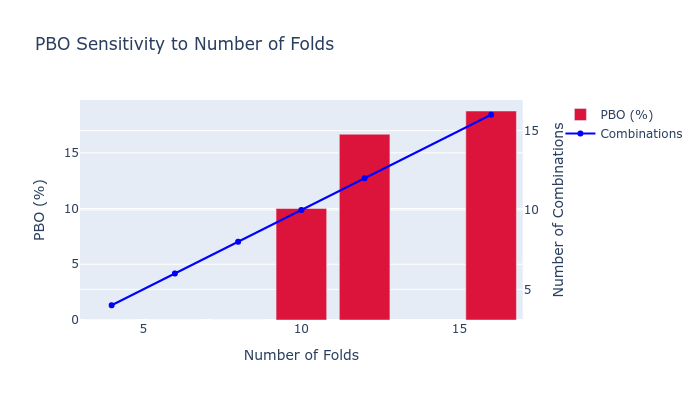

In [31]:
# Visualize PBO stability
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Bar(
        x=pbo_folds_df["n_folds"].to_list(),
        y=(pbo_folds_df["pbo"] * 100).to_list(),
        name="PBO (%)",
        marker_color="crimson",
    ),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(
        x=pbo_folds_df["n_folds"].to_list(),
        y=pbo_folds_df["n_combinations"].to_list(),
        name="Combinations",
        mode="lines+markers",
        line={"color": "blue"},
    ),
    secondary_y=True,
)

fig.update_layout(
    title="PBO Sensitivity to Number of Folds",
    xaxis_title="Number of Folds",
    height=400,
)
fig.update_yaxes(title_text="PBO (%)", secondary_y=False)
fig.update_yaxes(title_text="Number of Combinations", secondary_y=True)
show_plot(fig)

### 8.2 Case Study: When PBO Catches What DSR Misses

PBO can detect overfitting that DSR misses when:
- The strategy was selected from many alternatives on in-sample data
- The in-sample performance doesn't generalize out-of-sample
- The selected in-sample Sharpe is large enough that DSR clears its 95 %
  threshold even at the *true* trial count

Below, the best of 200 variants posts a high in-sample Sharpe but a
near-zero out-of-sample Sharpe. DSR deploys it — the selection-inflated
IS Sharpe overwhelms the multiple-testing penalty even when the true trial
count is used — while PBO, which compares in- and out-of-sample CV
performance directly, flags the overfit.

In [32]:
# Simulate overfitted strategy that passes DSR but fails PBO
np.random.seed(123)

# Strategy was actually selected from 200 variants, but only 10 reported
true_n_trials = 200
reported_n_trials = 10  # Under-reported

# Generate IS and OOS performance (heavily overfitted)
n_cv_folds = 10
is_perf_overfit = np.random.randn(n_cv_folds, true_n_trials) + 1.5  # Strong IS bias
oos_perf_overfit = np.random.randn(n_cv_folds, true_n_trials)  # No bias in OOS

# Pick the "best" strategy (max IS average)
is_means = is_perf_overfit.mean(axis=0)
oos_means = oos_perf_overfit.mean(axis=0)
best_idx = np.argmax(is_means)

# is_perf_overfit / oos_perf_overfit are per-fold Sharpe-scale scores (IS bias
# +1.5, OOS unbiased), so the selected strategy's Sharpe is the fold mean directly.
best_is_sharpe = float(is_means[best_idx])
best_oos_sharpe = float(oos_means[best_idx])

In [33]:
# Compute DSR with under-reported and true trial counts, compare to PBO
dsr_underreported = deflated_sharpe_ratio(
    observed_sharpe=best_is_sharpe,
    skewness=-0.3,
    kurtosis=4.0,
    n_samples=504,
    n_trials=reported_n_trials,  # Under-reported!
    variance_trials=0.3,
    return_format="probability",
)

# Compute DSR with true trial count
dsr_true = deflated_sharpe_ratio(
    observed_sharpe=best_is_sharpe,
    skewness=-0.3,
    kurtosis=4.0,
    n_samples=504,
    n_trials=true_n_trials,  # True count
    variance_trials=0.3,
    return_format="probability",
)

# Compute PBO (doesn't need trial count - uses actual CV data)
pbo_overfit = compute_pbo(
    is_performance=is_perf_overfit,
    oos_performance=oos_perf_overfit,
)
pbo_overfit_dict = pbo_overfit.to_dict() if hasattr(pbo_overfit, "to_dict") else pbo_overfit

print("\n" + "=" * 70)
print("CASE STUDY: PBO CATCHES HIDDEN OVERFITTING")
print("=" * 70)
print(f"\nTrue trials tested: {true_n_trials}")
print(f"Reported trials: {reported_n_trials}")
print(f"\nBest strategy IS Sharpe: {best_is_sharpe:.2f}")
print(f"Best strategy OOS Sharpe: {best_oos_sharpe:.2f}")
print(f"Performance degradation: {(best_is_sharpe - best_oos_sharpe):.2f}")

_dsr_pass = 0.95  # deploy threshold from the decision tree in 8.3
_pbo_reject = 0.25
_ur_verdict = "PASSES (would deploy)" if dsr_underreported >= _dsr_pass else "fails"
_true_verdict = "fails (correctly rejects)" if dsr_true < _dsr_pass else "PASSES"
_pbo_verdict = "FLAGS OVERFITTING" if pbo_overfit_dict["pbo"] > _pbo_reject else "does not flag"

print("\n--- DETECTION RESULTS ---")
print(f"DSR (under-reported trials={reported_n_trials}): {dsr_underreported:.1%} → {_ur_verdict}")
print(f"DSR (true trial count={true_n_trials}): {dsr_true:.1%} → {_true_verdict}")
print(f"PBO (from CV data): {pbo_overfit_dict['pbo']:.1%} → {_pbo_verdict}")

print("\nLesson: DSR can clear its threshold on a selection-inflated in-sample")
print("   Sharpe even at the true trial count. PBO uses actual CV performance,")
print("   so it catches the overfit the multiple-testing penalty misses.")


CASE STUDY: PBO CATCHES HIDDEN OVERFITTING

True trials tested: 200
Reported trials: 10

Best strategy IS Sharpe: 2.33
Best strategy OOS Sharpe: -0.07
Performance degradation: 2.40

--- DETECTION RESULTS ---
DSR (under-reported trials=10): 100.0% → PASSES (would deploy)
DSR (true trial count=200): 100.0% → PASSES
PBO (from CV data): 50.0% → FLAGS OVERFITTING

Lesson: DSR can clear its threshold on a selection-inflated in-sample
   Sharpe even at the true trial count. PBO uses actual CV performance,
   so it catches the overfit the multiple-testing penalty misses.


### 8.3 DSR vs PBO: When to Use Each

| Method | Best For | Measures |
|--------|----------|----------|
| **DSR** | Known trial count, parameter sweeps | Probability observed Sharpe is luck |
| **PBO** | Strategy selection from alternatives | Probability best IS overfit to IS period |
| **RAS** | Complex models, feature engineering | Sensitivity to return randomization |

**Decision Framework**:
```
┌─────────────────────────────────────────────────────────────────┐
│              BACKTEST VALIDATION DECISION TREE                 │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  1. Check DSR (if trial count known)                           │
│     └─ DSR < 95%? → REJECT: Selection bias too high            │
│                                                                 │
│  2. Check PBO (if CV results available)                        │
│     └─ PBO > 25%? → REJECT: Overfitting detected               │
│                                                                 │
│  3. Check RAS (if model complexity known)                      │
│     └─ RAS adjustment > 50%? → CAUTION: Model too complex      │
│                                                                 │
│  4. All pass? → PAPER TRADE before live deployment             │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘
```

**Recommendation**: Use multiple methods. If any raises red flags, investigate further.

## 9. Key Takeaways

### Critical Insights

1. **Selection bias is real**: Testing 100 strategies, the best will have SR > 2 by luck
2. **Non-normality matters**: Negative skew and fat tails reduce reliability
3. **DSR provides probability**: Not just "is it significant" but "probability of skill"
4. **PBO uses cross-validation**: Estimates overfitting through combinatorial splits
5. **Combine methods**: DSR, PBO, and RAS for comprehensive overfitting detection

### Practical Rules

1. **Always track trials**: Record every strategy variant tested
2. **Report DSR alongside raw Sharpe**: Be honest about multiple testing
3. **Use realistic parameters**: Include non-normality in calculations
4. **Set minimum thresholds**: Require DSR > 95% for production deployment

### Integration Checklist

- [ ] Count all strategy variants tested
- [ ] Calculate Sharpe variance across variants
- [ ] Measure return skewness and kurtosis
- [ ] Compute DSR with all parameters
- [ ] Compute PBO with combinatorial cross-validation
- [ ] Compare DSR, PBO, and RAS results
- [ ] Only deploy if DSR > 95% AND PBO < 25%

In [34]:
# Summary
print("=" * 80)
print("OVERFITTING DETECTION SUMMARY")
print("=" * 80)

print("\n1. SELECTION BIAS DEMONSTRATION:")
print(f"   - Tested 100 null strategies, best had SR = {results['max_sharpe']:.2f}")
print("   - This is pure luck, no skill!")

print("\n2. DSR DECAY WITH TRIALS:")
print(f"   - 1 trial: DSR = {dsr_df.row(0, named=True)['dsr_probability']:.1%}")
print(f"   - 100 trials: DSR = {dsr_df.row(5, named=True)['dsr_probability']:.1%}")
print(f"   - 500 trials: DSR = {dsr_df.row(7, named=True)['dsr_probability']:.1%}")

print("\n3. CASE STUDY RESULT:")
print(f"   - Best momentum variant: SR = {best['observed_sharpe']:.2f}")
print(f"   - Without correction (PSR): {psr_best:.1%}")
print(f"   - With DSR correction: {dsr_best:.1%}")

print("\n4. DSR vs RAS:")
print(f"   - DSR adjusted Sharpe: {dsr_adjusted_sharpe:.3f}")
print(f"   - RAS adjusted Sharpe: {ras_adjusted:.3f}")

print("\n5. PBO ANALYSIS:")
print(f"   - Probability of Backtest Overfitting: {pbo_value:.1%}")
print("   - Threshold: Deploy only if PBO < 25%")

print("\n" + "=" * 80)

OVERFITTING DETECTION SUMMARY

1. SELECTION BIAS DEMONSTRATION:
   - Tested 100 null strategies, best had SR = 2.54
   - This is pure luck, no skill!

2. DSR DECAY WITH TRIALS:
   - 1 trial: DSR = 100.0%
   - 100 trials: DSR = 0.0%
   - 500 trials: DSR = 0.0%

3. CASE STUDY RESULT:
   - Best momentum variant: SR = 2.50
   - Without correction (PSR): 100.0%
   - With DSR correction: 100.0%

4. DSR vs RAS:
   - DSR adjusted Sharpe: 0.321
   - RAS adjusted Sharpe: 1.829

5. PBO ANALYSIS:
   - Probability of Backtest Overfitting: 10.0%
   - Threshold: Deploy only if PBO < 25%

